# LightGBM Prediction Pipeline

This notebook follows the same technical-indicator benchmark format as the LSTM/BiLSTM notebooks, but replaces the neural sequence model with Microsoft LightGBM.

PDF concept summary:

- LightGBM is a tree-based Gradient Boosting Decision Tree model.
- It improves traditional GBDT training with histogram-based split search, Gradient-based One-Side Sampling (GOSS), and Exclusive Feature Bundling (EFB).
- This makes it a good fit for the flattened technical-indicator lag features produced by the existing tensor pipeline.

Implementation note:

- The model uses Microsoft LightGBM's official scikit-learn interface: `lightgbm.LGBMRegressor`.
- The existing 3-D tensor `(samples, lookback, features)` is flattened into tabular lag features before fitting LightGBM.


In [1]:
from pathlib import Path
import importlib
import json
import sys

import numpy as np
import pandas as pd
from IPython.display import Image, display

SRC_DIR = Path.cwd() / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

import lightgbm_benchmark
import plot_results

# Jupyter keeps imported modules cached. Reload project scripts after edits.
importlib.reload(lightgbm_benchmark)
importlib.reload(plot_results)

from benchmark_utils import INDEX_TICKERS
from indicator import add_technical_indicators
from lightgbm_benchmark import flatten_lag_features, run_lightgbm_benchmark
from plot_results import plot_price_predictions, plot_tensor_surface
from tensor_transform import build_lstm_tensors

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 140)


## Configuration

In [2]:
START = "2010-01-01"
END = "2026-06-01"
TRAIN_END = "2025-12-31"
TEST_START = "2026-01-01"
TEST_END = "2026-05-31"

LOOKBACK = 30
# 21 trading days is approximately one month. The input window still updates every trading day.
HORIZON = 1
TOP_K = 16
N_ESTIMATORS = 600
LEARNING_RATE = 0.03
NUM_LEAVES = 31

OUTPUT_DIR = Path(f"outputs_lightgbm_h{HORIZON}")
PLOTS_DIR = Path(f"plots_lightgbm_h{HORIZON}")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

# Set this to False if you only want to reload existing CSV outputs and regenerate plots.
RUN_TRAINING = True


## Train LightGBM And Build Benchmark Outputs

The target is horizon log return. Predicted log return is converted back to close price with:

```text
predicted_close = previous_close * exp(predicted_log_return)
```


In [3]:
if RUN_TRAINING:
    results = []
    for index_name, ticker in INDEX_TICKERS.items():
        print(f"Running LightGBM {index_name} ({ticker})...")
        result = run_lightgbm_benchmark(
            name=index_name,
            ticker=ticker,
            start=START,
            end=END,
            train_end=TRAIN_END,
            test_start=TEST_START,
            test_end=TEST_END,
            lookback=LOOKBACK,
            horizon=HORIZON,
            top_k=TOP_K,
            output_dir=OUTPUT_DIR,
            n_estimators=N_ESTIMATORS,
            learning_rate=LEARNING_RATE,
            num_leaves=NUM_LEAVES,
        )
        results.append(result)
        print(
            f"{index_name}: RMSE={result['rmse']:.2f}, MAE={result['mae']:.2f}, "
            f"MAPE={result['mape_pct']:.2f}%, Direction={result['direction_accuracy_pct']:.2f}%"
        )

    summary = pd.DataFrame(results)
    summary.to_csv(OUTPUT_DIR / "benchmark_summary.csv", index=False)
    (OUTPUT_DIR / "benchmark_summary.json").write_text(json.dumps(results, indent=2), encoding="utf-8")


Running LightGBM Nasdaq (^IXIC)...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.015275 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 122400
[LightGBM] [Info] Number of data points in the train set: 3345, number of used features: 480
[LightGBM] [Info] Start training from score -0.004701


c:\Users\zoufuc\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\zoufuc\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\zoufuc\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


Nasdaq: RMSE=264.84, MAE=211.61, MAPE=0.90%, Direction=56.86%
Running LightGBM SP500 (^GSPC)...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.016913 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 122400
[LightGBM] [Info] Number of data points in the train set: 3345, number of used features: 480
[LightGBM] [Info] Start training from score -0.004937


c:\Users\zoufuc\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\zoufuc\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\zoufuc\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


SP500: RMSE=57.95, MAE=44.62, MAPE=0.65%, Direction=56.86%
Running LightGBM SOX (^SOX)...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.015775 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 122400
[LightGBM] [Info] Number of data points in the train set: 3345, number of used features: 480
[LightGBM] [Info] Start training from score -0.004171
SOX: RMSE=231.02, MAE=179.11, MAPE=1.98%, Direction=66.67%


c:\Users\zoufuc\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\zoufuc\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\zoufuc\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


## Benchmark Summary

In [4]:
summary = pd.read_csv(OUTPUT_DIR / "benchmark_summary.csv")
metric_cols = [
    "index", "ticker", "model", "samples", "train_samples", "rmse", "mae", "mape_pct",
    "naive_rmse", "naive_mae", "rmse_vs_naive_pct", "mae_vs_naive_pct",
    "direction_accuracy_pct", "final_train_loss", "final_val_loss", "best_iteration",
]
summary[metric_cols]


,index,ticker,model,samples,train_samples,rmse,mae,mape_pct,naive_rmse,naive_mae,rmse_vs_naive_pct,mae_vs_naive_pct,direction_accuracy_pct,final_train_loss,final_val_loss,best_iteration
0,Nasdaq,^IXIC,LightGBM,102,3935,264.839466,211.612372,0.904311,265.655273,212.978867,0.307093,0.641611,56.862745,0.991594,0.994845,1
1,SP500,^GSPC,LightGBM,102,3935,57.951832,44.618321,0.646602,58.252670,44.949280,0.516437,0.736294,56.862745,1.026903,0.785549,1
2,SOX,^SOX,LightGBM,102,3935,231.022567,179.110841,1.975313,232.848175,180.839233,0.784034,0.955762,66.666667,0.915819,1.430320,1


## Inspect Feature IC Ranking And LightGBM Importance

In [5]:
feature_ic = {
    index_name: pd.read_csv(OUTPUT_DIR / f"{index_name}_feature_ic.csv").head(TOP_K)
    for index_name in summary["index"]
}
feature_importance = {
    index_name: pd.read_csv(OUTPUT_DIR / f"{index_name}_feature_importance.csv").head(20)
    for index_name in summary["index"]
}

feature_ic["Nasdaq"], feature_importance["Nasdaq"]


(            feature        ic    abs_ic
 0               Low  0.999640  0.999640
 1              High  0.999632  0.999632
 2              Open  0.999549  0.999549
 3              MA_5  0.999406  0.999406
 4            EMA_12  0.999116  0.999116
 5             MA_10  0.999029  0.999029
 6            EMA_26  0.998329  0.998329
 7             MA_20  0.998256  0.998256
 8             MA_60  0.995249  0.995249
 9            Volume  0.882157  0.882157
 10      MACD_signal  0.299533  0.299533
 11             MACD  0.283237  0.283237
 12    Volatility_10  0.112048  0.112048
 13   Close_to_MA_60  0.109847  0.109847
 14     HL_range_pct  0.105599  0.105599
 15  Close_to_EMA_26  0.075861  0.075861,
                    feature  importance
 0       HL_range_pct_lag_9           2
 1    Close_to_EMA_26_lag_6           2
 2               MACD_lag_2           1
 3   Close_to_EMA_26_lag_16           1
 4     Close_to_MA_60_lag_2           1
 5       HL_range_pct_lag_2           1
 6    Close_to_EMA_26_

## Build One Flattened Tensor Manually

This cell demonstrates how the imported tensor path becomes the tabular lag matrix consumed by `LGBMRegressor`.

In [6]:
example_index = "Nasdaq"
raw = pd.read_csv(OUTPUT_DIR / f"{example_index}_raw.csv", index_col=0, parse_dates=True)
features_df = add_technical_indicators(raw)
selected_features = pd.read_csv(OUTPUT_DIR / f"{example_index}_feature_ic.csv")["feature"].head(TOP_K).tolist()

tensor_data = build_lstm_tensors(
    features_df,
    feature_columns=selected_features,
    lookback=LOOKBACK,
    horizon=HORIZON,
    train_end=TRAIN_END,
    test_start=TEST_START,
    test_end=TEST_END,
    target_mode="log_return",
)
X_flat, flat_names = flatten_lag_features(tensor_data.X_test, selected_features, LOOKBACK)

print("X_test tensor", tensor_data.X_test.shape)
print("X_test flattened", X_flat.shape)
pd.DataFrame([X_flat[0]], columns=flat_names)


X_test tensor (102, 30, 16)
X_test flattened (102, 480)


,Low_lag_30,High_lag_30,Open_lag_30,MA_5_lag_30,EMA_12_lag_30,MA_10_lag_30,EMA_26_lag_30,MA_20_lag_30,MA_60_lag_30,Volume_lag_30,MACD_signal_lag_30,MACD_lag_30,Volatility_10_lag_30,Close_to_MA_60_lag_30,HL_range_pct_lag_30,Close_to_EMA_26_lag_30,Low_lag_29,High_lag_29,Open_lag_29,MA_5_lag_29,EMA_12_lag_29,MA_10_lag_29,EMA_26_lag_29,MA_20_lag_29,MA_60_lag_29,...,MA_20_lag_2,MA_60_lag_2,Volume_lag_2,MACD_signal_lag_2,MACD_lag_2,Volatility_10_lag_2,Close_to_MA_60_lag_2,HL_range_pct_lag_2,Close_to_EMA_26_lag_2,Low_lag_1,High_lag_1,Open_lag_1,MA_5_lag_1,EMA_12_lag_1,MA_10_lag_1,EMA_26_lag_1,MA_20_lag_1,MA_60_lag_1,Volume_lag_1,MACD_signal_lag_1,MACD_lag_1,Volatility_10_lag_1,Close_to_MA_60_lag_1,HL_range_pct_lag_1,Close_to_EMA_26_lag_1
0,2.5807,2.597069,2.61074,2.672675,2.718267,2.72261,2.744937,2.776356,2.727402,2.442821,0.743303,-0.35053,0.264272,-0.579829,0.570785,-1.234608,2.609494,2.629891,2.590971,2.641386,2.704569,2.705193,2.738145,2.774708,2.730639,...,2.796094,2.822015,1.590624,0.316499,0.400691,-0.288009,-0.130254,-0.969256,-0.076006,2.768832,2.744807,2.769252,2.785,2.779363,2.768548,2.7907,2.794489,2.822968,1.185081,0.309102,0.262935,-0.225529,-0.295931,-0.480049,-0.344742


## Generate Tensor And Price Prediction Plots

In [7]:
for index_name in summary["index"]:
    plot_tensor_surface(
        index_name=index_name,
        raw_path=OUTPUT_DIR / f"{index_name}_raw.csv",
        feature_ic_path=OUTPUT_DIR / f"{index_name}_feature_ic.csv",
        output_path=PLOTS_DIR / f"{index_name}_tensor_3d.png",
        lookback=LOOKBACK,
        horizon=HORIZON,
        top_k=TOP_K,
        train_end=TRAIN_END,
        test_start=TEST_START,
        test_end=TEST_END,
    )
    plot_price_predictions(
        index_name=index_name,
        prediction_path=OUTPUT_DIR / f"{index_name}_predictions.csv",
        output_path=PLOTS_DIR / f"{index_name}_price_prediction.png",
    )

print(f"Saved plots to {PLOTS_DIR.resolve()}")


Saved plots to C:\Users\zoufuc\Desktop\Time-Series-Data-Prediction\plots_lightgbm_h1


## Display Example Plot

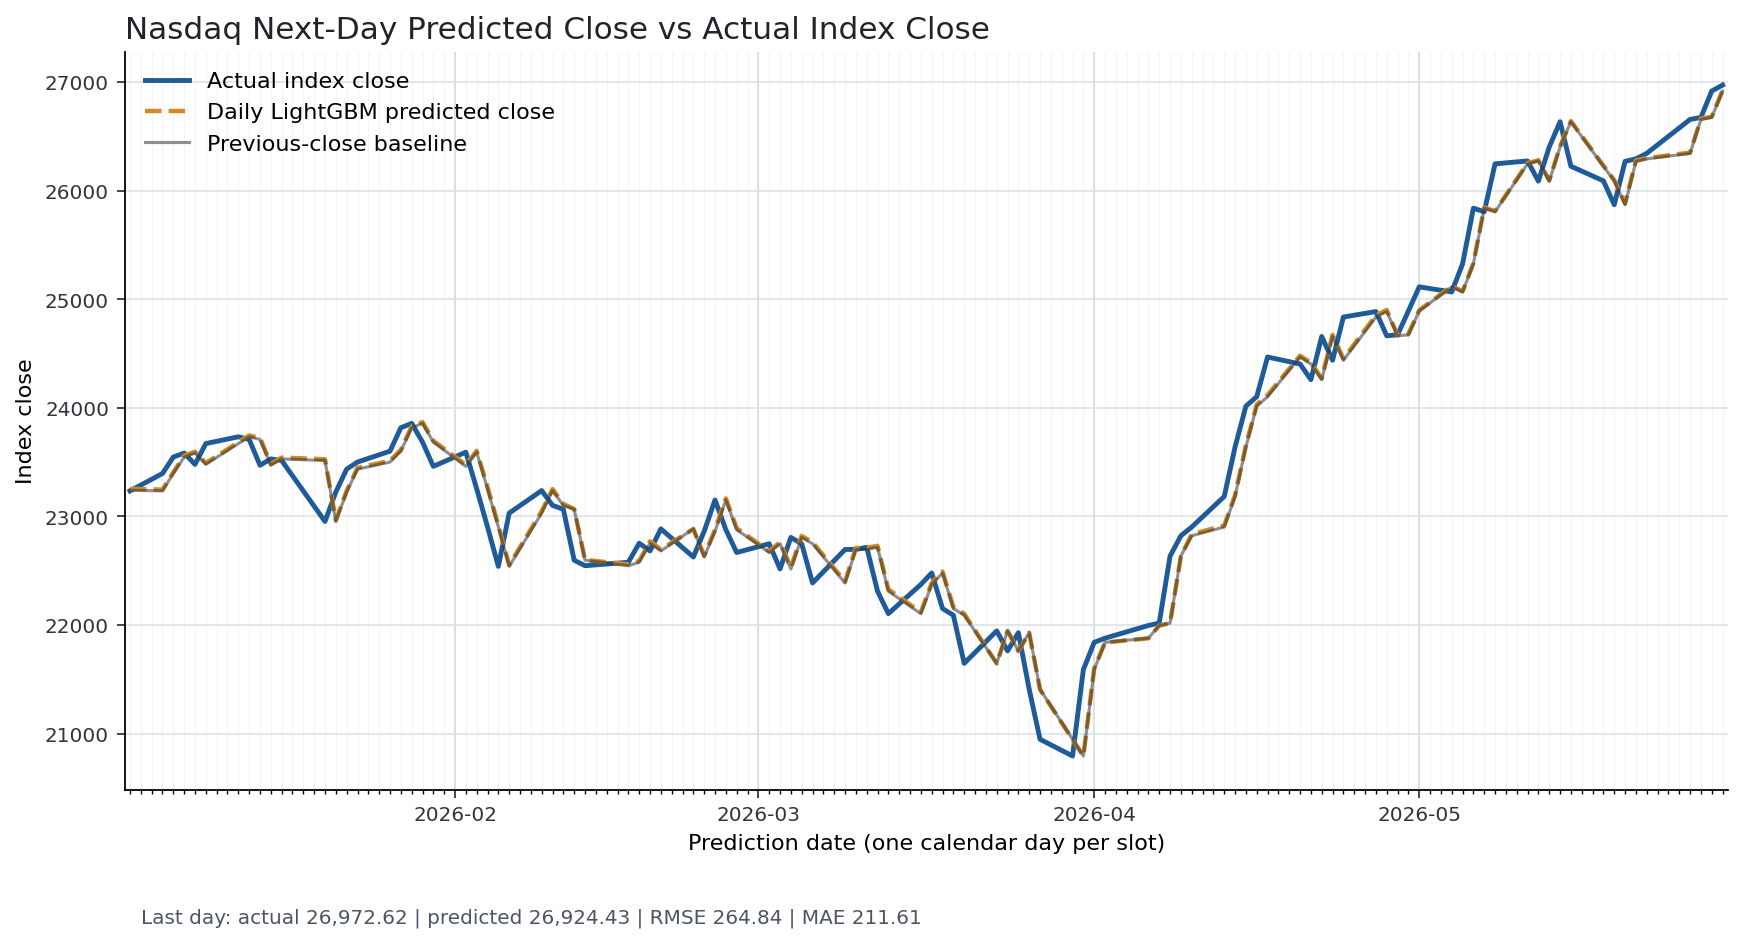

In [8]:
example_plot = PLOTS_DIR / "Nasdaq_price_prediction.png"
if example_plot.exists():
    display(Image(filename=str(example_plot)))
else:
    print(f"Plot not found: {example_plot}")
